In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Load CSVs into SQLite database
conn = sqlite3.connect(':memory:')

covid = pd.read_csv('datasets/covid_19_india.csv')
testing = pd.read_csv('datasets/StatewiseTestingDetails.csv')
vaccine = pd.read_csv('datasets/covid_vaccine_statewise.csv')

# --- Clean inconsistent state names ---
# Source data has whitespace, trailing asterisks (e.g. 'Maharashtra***'),
# and typos (e.g. 'Karanataka', 'Himanchal Pradesh') that create
# duplicate rows for the same state. Normalize before analysis.
STATE_NAME_FIXES = {
    'Karanataka': 'Karnataka',
    'Himanchal Pradesh': 'Himachal Pradesh',
    'Telengana': 'Telangana',
    'Telengana***': 'Telangana',
    'Telangana***': 'Telangana',
    'Maharashtra***': 'Maharashtra',
    'Madhya Pradesh***': 'Madhya Pradesh',
    'Karnataka***': 'Karnataka',
    'Nagaland#': 'Nagaland',
    'Jharkhand#': 'Jharkhand',
}

def clean_state_names(df, col):
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].str.replace(r'[*#]+$', '', regex=True).str.strip()
    df[col] = df[col].replace(STATE_NAME_FIXES)
    return df

covid = clean_state_names(covid, 'State/UnionTerritory')
testing = clean_state_names(testing, 'State')
vaccine = clean_state_names(vaccine, 'State')

covid.to_sql('cases', conn, index=False, if_exists='replace')
testing.to_sql('testing', conn, index=False, if_exists='replace')
vaccine.to_sql('vaccine', conn, index=False, if_exists='replace')

print("Database created successfully")
print("Tables: cases, testing, vaccine")

Database created successfully
Tables: cases, testing, vaccine


Top 10 Most Affected States:
            State  Total_Cases  Total_Deaths  Total_Recovered
0     Maharashtra      6363442        134201          6159676
1          Kerala      3586693         18004          3396184
2       Karnataka      2921049         36848          2861499
3      Tamil Nadu      2579130         34367          2524400
4  Andhra Pradesh      1985182         13564          1952736
5   Uttar Pradesh      1708812         22775          1685492
6     West Bengal      1534999         18252          1506532
7           Delhi      1436852         25068          1411280
8    Chhattisgarh      1003356         13544           988189
9          Odisha       988997          6565           972710

Top 10 States by Death Rate:
              State  Deaths  Confirmed  Death_Rate
0            Punjab   16322     599573        2.72
1       Uttarakhand    7368     342462        2.15
2       Maharashtra  134201    6363442        2.11
3          Nagaland     585      28811        2.03
4   

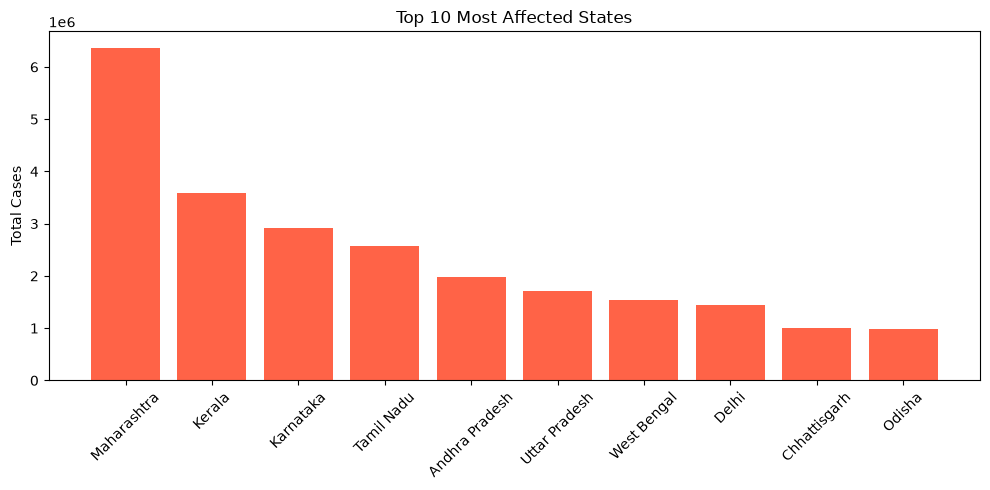

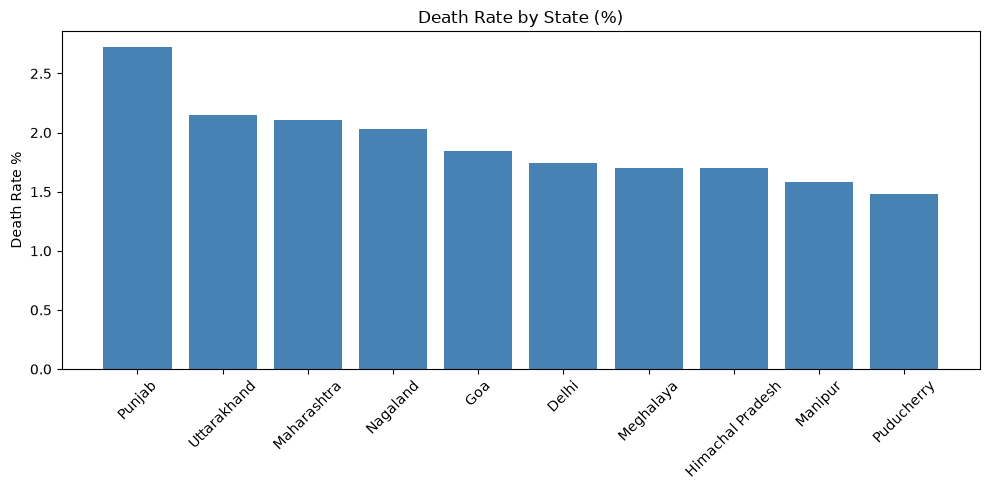

In [4]:
# Query 1 — Top 10 most affected states
q1 = pd.read_sql_query("""
    SELECT "State/UnionTerritory" as State,
           MAX(Confirmed) as Total_Cases,
           MAX(Deaths) as Total_Deaths,
           MAX(Cured) as Total_Recovered
    FROM cases
    GROUP BY "State/UnionTerritory"
    ORDER BY Total_Cases DESC
    LIMIT 10
""", conn)
print("Top 10 Most Affected States:")
print(q1)

# Query 2 — Death rate by state
# Note: filtering moved from WHERE to HAVING. Confirmed is cumulative, so
# WHERE Confirmed > 10000 filtered individual daily rows rather than the
# state's final total; MAX() over the remaining rows happened to give the
# same result here, but HAVING MAX(Confirmed) > 10000 correctly expresses
# 'filter on the state's total', not on individual rows.
q2 = pd.read_sql_query("""
    SELECT "State/UnionTerritory" as State,
           MAX(Deaths) as Deaths,
           MAX(Confirmed) as Confirmed,
           ROUND(CAST(MAX(Deaths) AS FLOAT) / MAX(Confirmed) * 100, 2) as Death_Rate
    FROM cases
    GROUP BY "State/UnionTerritory"
    HAVING MAX(Confirmed) > 10000
    ORDER BY Death_Rate DESC
    LIMIT 10
""", conn)
print("\nTop 10 States by Death Rate:")
print(q2)

# Query 3 — Monthly new-cases trend
# Fix: Confirmed is a CUMULATIVE count per state per day, so SUM(Confirmed)
# grouped by month massively overcounts (it sums running totals, not new
# cases). Correct approach: take each state's cumulative total at month-end,
# then subtract the previous month's cumulative total to get that month's
# new cases, then sum across states for the national monthly trend.
q3 = pd.read_sql_query("""
    WITH monthly_state_cumulative AS (
        SELECT "State/UnionTerritory" as State,
               SUBSTR(Date, 1, 7) as Month,
               MAX(Confirmed) as Cumulative_Confirmed
        FROM cases
        GROUP BY State, Month
    ),
    monthly_state_new AS (
        SELECT State, Month, Cumulative_Confirmed,
               LAG(Cumulative_Confirmed) OVER (PARTITION BY State ORDER BY Month) as Prev_Cumulative
        FROM monthly_state_cumulative
    )
    SELECT Month,
           SUM(Cumulative_Confirmed - COALESCE(Prev_Cumulative, 0)) as Total_New_Cases
    FROM monthly_state_new
    GROUP BY Month
    ORDER BY Month
""", conn)
print("\nMonthly New Cases Trend:")
print(q3.head(10))

# Query 4 — States with highest positivity rate
# Fix: Positive and TotalSamples are also CUMULATIVE per state per day, so
# SUM()-ing them across all days double/triple counts. Correct approach:
# use each state's LATEST (most recent date) cumulative Positive and
# TotalSamples, then compute Positive / TotalSamples directly.
q4 = pd.read_sql_query("""
    WITH latest_testing_date AS (
        SELECT State, MAX(Date) as Latest_Date
        FROM testing
        GROUP BY State
    ),
    latest_values AS (
        SELECT t.State,
               CAST(t.Positive AS FLOAT) as Total_Positive,
               CAST(t.TotalSamples AS FLOAT) as Total_Tested
        FROM testing t
        JOIN latest_testing_date ltd
            ON t.State = ltd.State AND t.Date = ltd.Latest_Date
        WHERE t.TotalSamples IS NOT NULL AND t.TotalSamples != ''
              AND t.Positive IS NOT NULL AND t.Positive != ''
    )
    SELECT State, Total_Positive, Total_Tested,
           ROUND(Total_Positive / Total_Tested * 100, 2) as Positivity_Rate
    FROM latest_values
    ORDER BY Positivity_Rate DESC
    LIMIT 10
""", conn)
print("\nTop 10 States by Positivity Rate (latest cumulative values):")
print(q4)

# Query 5 — Total vaccine doses administered by state
# Fix: dataset includes an 'India' row (national aggregate), which is not
# a state and was showing up in 'top states' results. Excluded here.
# Renamed from 'Vaccine Coverage' to 'Total Vaccine Doses Administered'
# since this measures raw dose counts, not a coverage rate (e.g. % of
# population vaccinated), which would need population data to compute.
q5 = pd.read_sql_query("""
    SELECT State,
           MAX("Total Doses Administered") as Total_Doses,
           MAX("Total Individuals Vaccinated") as Total_Vaccinated
    FROM vaccine
    WHERE State != 'India'
    GROUP BY State
    ORDER BY Total_Doses DESC
    LIMIT 10
""", conn)
print("\nTop 10 States by Total Vaccine Doses Administered:")
print(q5)

# Plot — Top 10 states by cases
plt.figure(figsize=(10,5))
plt.bar(q1['State'], q1['Total_Cases'], color='tomato')
plt.title('Top 10 Most Affected States')
plt.xticks(rotation=45)
plt.ylabel('Total Cases')
plt.tight_layout()
plt.show()

# Plot — Death rate
plt.figure(figsize=(10,5))
plt.bar(q2['State'], q2['Death_Rate'], color='steelblue')
plt.title('Death Rate by State (%)')
plt.xticks(rotation=45)
plt.ylabel('Death Rate %')
plt.tight_layout()
plt.show()